# Qwen2-VL-2B Model Evaluation

This notebook evaluates the performance of Qwen-VL-2.5B model on our fire detection dataset.

In [5]:
# For virtual environment only, ignore this cell if you're using personal computer
!source ../../miniconda3/bin/activate
!conda --version

conda 24.11.3


In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, Qwen2_5_VLProcessor, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
from qwen_vl_utils import process_vision_info
import matplotlib.pyplot as plt
import time
import re, json

In [7]:
# Load ground truth data
df = pd.read_csv('../FIRENET.csv')
print(f"Total samples in dataset: {len(df)}")
df.head()

Total samples in dataset: 502


,image_path,label,caption
0,FIRENET/train/image1.jpg,dangerous fire,The image shows a car engulfed in flames on a ...
1,FIRENET/train/image2.jpg,dangerous fire,The image shows a scene of a fire on the side ...
2,FIRENET/train/image3.jpg,controlled fire,A person holding a lit cigarette with smoke ri...
3,FIRENET/train/image4.jpg,controlled fire,The image shows a single cupcake with pink fro...
4,FIRENET/train/image5.jpg,dangerous fire,"A car is engulfed in flames on a street, with ..."


In [8]:
# Initialize model and processor
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16
)

processor = Qwen2_5_VLProcessor.from_pretrained(model_name,use_fast=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
    trust_remote_code=True,
    quantization_config = bnb_config
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def process_image(image_path):
    """Process a single image and return the model's prediction, caption and inference time"""
    try:
        # Start timing
        start_time = time.time()
        
        # Load image
        image = Image.open(image_path).convert("RGB")
        
        # Fire analysis prompt
        system_prompt = (
            "You are a visual analyst evaluating an image for signs of fire and the surrounding context. "
            "Perform the following tasks:\n"
            "1: Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.\n"
            "2: Based on your summary, classify the fire situation into one of the following three categories:\n"
            "- **No fire**: The image may contain symbols, representations, or objects related to fire, but no actual fire or smoke is present. This includes things like warning signs, fire safety equipment (extinguishers, alarms), digital or printed representations of fire (e.g., a laptop screen showing fire, a drawing or painting).\n"
            "- **Controlled fire**: There is a visible flame or heat source, but it is clearly contained, expected, and managed by people or objects in its environment. This includes fireplaces, campfires, cooking appliances, lit candles, lighters, or matchsticks. There should be no signs of danger, spread, panic, or damage in the surroundings.\n"
            "- **Dangerous (uncontrolled) fire**: The fire appears out of control or harmful to the environment or people. Signs include flames spreading to flammable materials (e.g., curtains, furniture, bedding), thick smoke near the ceiling, charring, visible structural damage, or people reacting with fear or urgency. The context suggests potential or ongoing property damage or bodily harm.\n"
            "3: Briefly explain your reasoning behind the classification (1-2 sentences).\n"
            "Return only this JSON format:\n"
            "{ \"caption\": \"...\", \"label\": \"no fire\"|\"controlled fire\"|\"dangerous fire\", \"explanation\": \"...\" }"
        )

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": system_prompt}
            ]
        }]

        # Generate prompt and inputs
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages) #this is for qwen family only, for other models please remove
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(device)

        # Generate response
        with torch.no_grad():
            generate_ids = model.generate(
                **inputs,
                max_new_tokens=1024,
                do_sample=True,
                top_k=50,
                top_p=0.95,
                num_return_sequences=1,
            )
        
        output = processor.tokenizer.batch_decode(generate_ids, skip_special_tokens=True)[0]
        if output.startswith("system"):
            output = output.split("assistant", 1)[-1].strip()

        clean_output = re.sub(r'^(system|user|assistant)\n', '', output, flags=re.MULTILINE).strip()

        # Match the last complete JSON block
        matches = re.findall(r'\{[^{}]+\}', clean_output, re.DOTALL)
        if matches:
            try:
                result = json.loads(matches[-1])  # take the last match (most likely correct)
                caption = result.get("caption", "").strip()
                label = result.get("label", "").strip()
            except Exception as e:
                print(f"❌ Failed to parse JSON for {image_path}: {e}")
                caption = clean_output
                label = "unknown"
        else:
            print(f"❌ No JSON block found in output for {image_path}")
            caption = clean_output
            label = "unknown"

        # Calculate inference time
        inference_time = time.time() - start_time
        
        return label, caption, inference_time
            
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return "error", "", 0.0

In [12]:
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    img_path = os.path.join('../', row['image_path'])
    if os.path.exists(img_path):
        pred, caption, inf_time = process_image(img_path)
        predictions.append(pred)
        captions.append(caption)
        inference_times.append(inf_time)
        ground_truth.append(row['label'])
        if idx % 10 == 0:
            print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

Processed 0 images... Average inference time so far: 7.035s
Processed 10 images... Average inference time so far: 6.352s
Processed 20 images... Average inference time so far: 6.237s
Processed 30 images... Average inference time so far: 6.199s
Processed 40 images... Average inference time so far: 6.210s
Processed 50 images... Average inference time so far: 6.149s
Processed 60 images... Average inference time so far: 6.096s
Processed 70 images... Average inference time so far: 6.028s
Processed 80 images... Average inference time so far: 6.093s
Processed 90 images... Average inference time so far: 6.129s
Processed 100 images... Average inference time so far: 6.098s
Processed 110 images... Average inference time so far: 6.090s
Processed 120 images... Average inference time so far: 6.119s
Processed 130 images... Average inference time so far: 6.183s
Processed 140 images... Average inference time so far: 6.198s
Processed 150 images... Average inference time so far: 6.176s
Processed 160 image

In [13]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv('qwen2.5_vl_3B_results.csv', index=False)
print("Results saved to qwen2.5_vl_3B_base_results.csv")

Results saved to qwen2.5_vl_3B_base_results.csv


In [14]:
# Load the CSV file
df = pd.read_csv("qwen2.5_vl_3B_results.csv")
df = df.dropna(subset=['true_label', 'predicted_label', 'inference_time'])  # Remove rows with missing values

# Extract relevant columns
ground_truth = df['true_label'].astype(str).str.strip()
predictions = df['predicted_label'].astype(str).str.strip()
inference_times = df['inference_time'].astype(float)

# Calculate classification metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth, predictions, average='weighted'
)

# Print performance metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Inference time stats
print("\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.9084
Precision: 0.9768
Recall: 0.9084
F1 Score: 0.9369

Inference Time Statistics:
Average: 6.161s
Std Dev: 0.945s
Min: 3.927s
Max: 9.897s


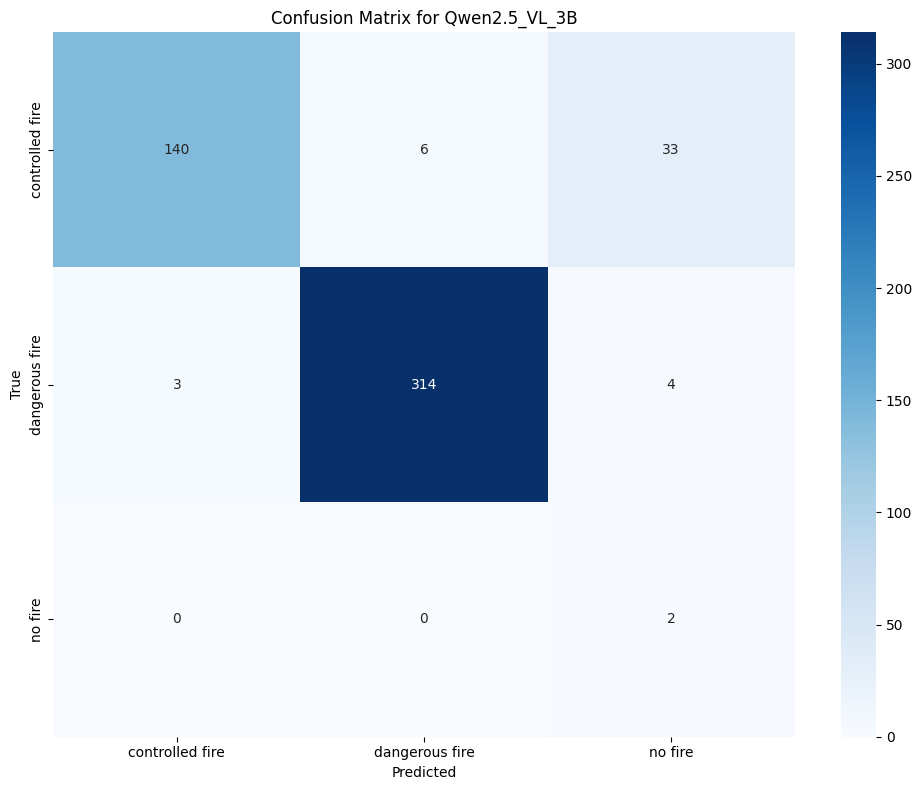

In [15]:
# Confusion matrix
labels = sorted(df['true_label'].unique())
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix for Qwen2.5_VL_3B')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()